In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/final_data.csv')
print(f"Shape: {df.shape}")

X = df.drop(columns=['TARGET'])
y = df['TARGET']

print(f"Features: {X.shape[1]}")
print(f"Class distribution:\n{y.value_counts()}")

Shape: (307511, 56)
Features: 55
Class distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # maintains class ratio in both splits
)

print(f"Training set:   {X_train.shape}")
print(f"Test set:       {X_test.shape}")
print(f"\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set:   (246008, 55)
Test set:       (61503, 55)

Train target distribution:
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64

Test target distribution:
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64


In [6]:
print(f"Before SMOTE - Train class distribution:")
print(y_train.value_counts())

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE - Train class distribution:")
print(pd.Series(y_train_sm).value_counts())
print(f"\nNew training shape: {X_train_sm.shape}")

Before SMOTE - Train class distribution:
TARGET
0    226148
1     19860
Name: count, dtype: int64

After SMOTE - Train class distribution:
TARGET
0    226148
1    226148
Name: count, dtype: int64

New training shape: (452296, 55)


In [4]:
print("Test set class distribution (must match original):")
print(y_test.value_counts(normalize=True).round(3))
print(f"\nTest set shape: {X_test.shape}")
print("Test set contains NO synthetic samples")

Test set class distribution (must match original):
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64

Test set shape: (61503, 55)
Test set contains NO synthetic samples


In [7]:
# Save for use across model notebooks
import os
os.makedirs('../data/processed/splits', exist_ok=True)

X_train_sm.to_csv('../data/processed/splits/X_train.csv', index=False)
X_test.to_csv('../data/processed/splits/X_test.csv', index=False)
pd.Series(y_train_sm).to_csv('../data/processed/splits/y_train.csv', index=False)
y_test.to_csv('../data/processed/splits/y_test.csv', index=False)

print("All splits saved to data/processed/splits/")

All splits saved to data/processed/splits/


In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

X_train = pd.read_csv('../data/processed/splits/X_train.csv')
X_test  = pd.read_csv('../data/processed/splits/X_test.csv')
y_train = pd.read_csv('../data/processed/splits/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/splits/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (452296, 55)
X_test:  (61503, 55)


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [10]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        random_state=42,
        class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=7,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        eval_metric='auc',
        verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        class_weight='balanced',
        verbose=-1
    )
}

In [12]:
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    # Logistic Regression needs scaled data
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'y_prob': y_prob, 'auc': auc}
    print(f"  ROC-AUC: {auc:.4f}")

print("\nDone.")

Training Logistic Regression...
  ROC-AUC: 0.6378
Training Random Forest...
  ROC-AUC: 0.6927
Training XGBoost...
  ROC-AUC: 0.7006
Training LightGBM...
  ROC-AUC: 0.7012

Done.


In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

print("=" * 40)
print(f"{'Model':<25} {'ROC-AUC':>10}")
print("=" * 40)
for name, res in results.items():
    print(f"{name:<25} {res['auc']:>10.4f}")
print("=" * 40)

Model                        ROC-AUC
Logistic Regression           0.6378
Random Forest                 0.6927
XGBoost                       0.7006
LightGBM                      0.7012


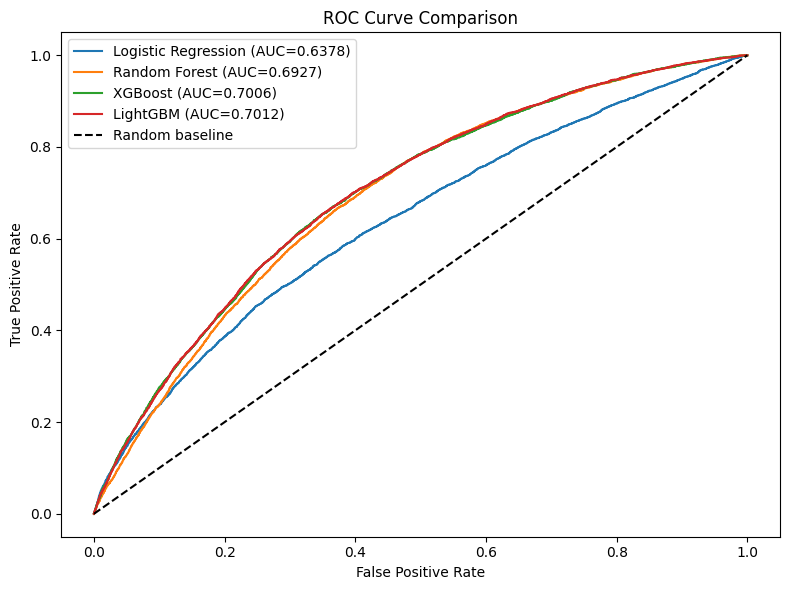

In [14]:
# ROC Curve comparison
fig, ax = plt.subplots(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.4f})")

ax.plot([0,1], [0,1], 'k--', label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import numpy as np

# Get best model
best_model = results['LightGBM']['model']
y_prob     = results['LightGBM']['y_prob']
y_pred     = (y_prob >= 0.5).astype(int)

print("Classification Report (threshold=0.5):")
print(classification_report(y_test, y_pred, target_names=['Repaid', 'Defaulted']))

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

      Repaid       0.92      0.98      0.95     56538
   Defaulted       0.23      0.07      0.11      4965

    accuracy                           0.91     61503
   macro avg       0.58      0.52      0.53     61503
weighted avg       0.87      0.91      0.88     61503



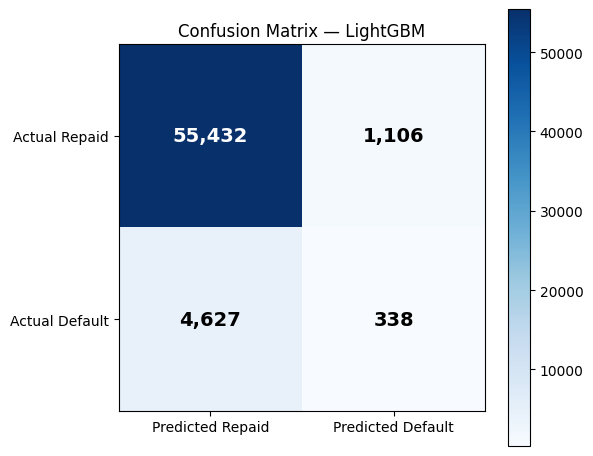


True Negatives  (Correct Repaid):    55,432
False Positives (Wrong Default flag): 1,106
False Negatives (Missed Defaulters):  4,627
True Positives  (Caught Defaulters):  338


In [16]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted Repaid', 'Predicted Default'])
ax.set_yticklabels(['Actual Repaid', 'Actual Default'])

for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}', 
                ha='center', va='center', 
                fontsize=14, fontweight='bold',
                color='white' if cm[i,j] > cm.max()/2 else 'black')

ax.set_title('Confusion Matrix — LightGBM')
plt.colorbar(im)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (Correct Repaid):    {tn:,}")
print(f"False Positives (Wrong Default flag): {fp:,}")
print(f"False Negatives (Missed Defaulters):  {fn:,}")
print(f"True Positives  (Caught Defaulters):  {tp:,}")

In [17]:
# Default threshold of 0.5 is rarely optimal for imbalanced data
# Find threshold that maximizes F1 for defaulters

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"Best F1 score:  {f1_scores[best_idx]:.4f}")

Best threshold: 0.1883
Best F1 score:  0.2434


In [18]:
# Evaluate at best threshold
y_pred_tuned = (y_prob >= best_threshold).astype(int)

print(f"\nClassification Report (threshold={best_threshold:.4f}):")
print(classification_report(y_test, y_pred_tuned, 
                            target_names=['Repaid', 'Defaulted']))


Classification Report (threshold=0.1883):
              precision    recall  f1-score   support

      Repaid       0.95      0.75      0.84     56538
   Defaulted       0.16      0.53      0.24      4965

    accuracy                           0.73     61503
   macro avg       0.55      0.64      0.54     61503
weighted avg       0.88      0.73      0.79     61503



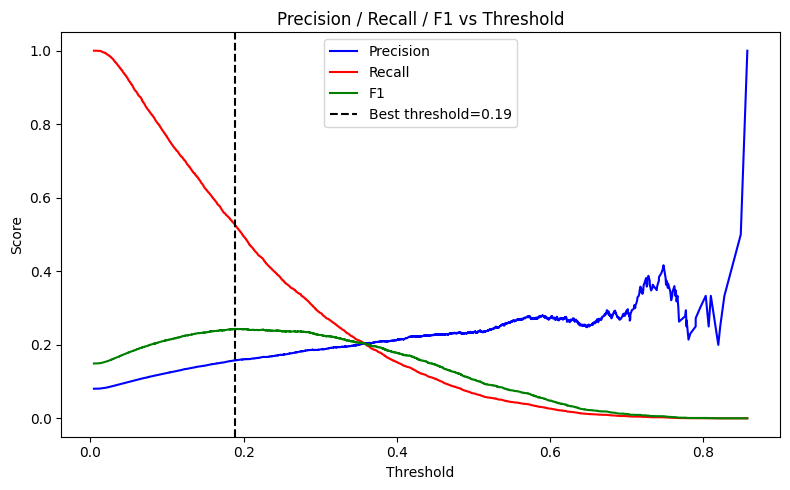

In [19]:
# Plot Precision-Recall tradeoff
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions[:-1], label='Precision', color='blue')
ax.plot(thresholds, recalls[:-1], label='Recall', color='red')
ax.plot(thresholds, f1_scores[:-1], label='F1', color='green')
ax.axvline(x=best_threshold, color='black', linestyle='--', 
           label=f'Best threshold={best_threshold:.2f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Threshold')
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
dummy_accuracy = (y_test == 0).mean()
lgbm_accuracy  = (y_pred == y_test).mean()

print("=" * 45)
print(f"Dummy model accuracy (predict all 0): {dummy_accuracy:.4f}")
print(f"LightGBM accuracy:                    {lgbm_accuracy:.4f}")
print("=" * 45)
print("\nA model that predicts EVERYONE repays gets")
print(f"{dummy_accuracy*100:.1f}% accuracy — yet catches ZERO defaulters.")
print("This is why we use ROC-AUC, Recall, and F1.")

Dummy model accuracy (predict all 0): 0.9193
LightGBM accuracy:                    0.9068

A model that predicts EVERYONE repays gets
91.9% accuracy — yet catches ZERO defaulters.
This is why we use ROC-AUC, Recall, and F1.


In [1]:
import pandas as pd
import numpy as np

X_test = pd.read_csv('../data/processed/splits/X_test.csv')
y_test = pd.read_csv('../data/processed/splits/y_test.csv').squeeze()

import joblib
model = joblib.load('../models/lgbm_best_model.pkl')
y_prob = model.predict_proba(X_test)[:, 1]

# Build a results dataframe
results = X_test.copy()
results['ACTUAL'] = y_test.values
results['PREDICTED_PROB'] = y_prob

# Find clear cases
confirmed_defaulters = results[results['ACTUAL'] == 1].nlargest(5, 'PREDICTED_PROB')
confirmed_repayers   = results[results['ACTUAL'] == 0].nsmallest(5, 'PREDICTED_PROB')
model_wrong          = results[
    (results['ACTUAL'] == 1) & (results['PREDICTED_PROB'] < 0.2)
].head(3)

print("=== TOP 5 CONFIRMED DEFAULTERS ===")
print(confirmed_defaulters[['ACTUAL', 'PREDICTED_PROB', 
                             'EXT_SOURCE_MEAN', 'CREDIT_TO_INCOME_RATIO',
                             'AMT_INCOME_TOTAL', 'AMT_CREDIT', 
                             'AMT_ANNUITY', 'DAYS_BIRTH', 
                             'DAYS_EMPLOYED', 'EXT_SOURCE_1',
                             'EXT_SOURCE_2', 'EXT_SOURCE_3']].to_string())

print("\n=== TOP 5 CONFIRMED REPAYERS ===")
print(confirmed_repayers[['ACTUAL', 'PREDICTED_PROB',
                           'EXT_SOURCE_MEAN', 'CREDIT_TO_INCOME_RATIO',
                           'AMT_INCOME_TOTAL', 'AMT_CREDIT',
                           'AMT_ANNUITY', 'DAYS_BIRTH',
                           'DAYS_EMPLOYED', 'EXT_SOURCE_1',
                           'EXT_SOURCE_2', 'EXT_SOURCE_3']].to_string())

print("\n=== MODEL WAS WRONG (Missed Defaulters) ===")
print(model_wrong[['ACTUAL', 'PREDICTED_PROB',
                   'EXT_SOURCE_MEAN', 'CREDIT_TO_INCOME_RATIO']].to_string())

=== TOP 5 CONFIRMED DEFAULTERS ===
       ACTUAL  PREDICTED_PROB  EXT_SOURCE_MEAN  CREDIT_TO_INCOME_RATIO  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  DAYS_BIRTH  DAYS_EMPLOYED  EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3
56778       1        0.804845         0.238247                2.053714          126000.0    258768.0      17505.0      -13642         -501.0      0.505998      0.033137      0.175606
2367        1        0.801133         0.218248                3.525565          103500.0    364896.0      28957.5      -14597         -271.0      0.505998      0.013641      0.135106
21231       1        0.787232         0.400323                4.042857          126000.0    509400.0      37197.0      -11907        -1539.0      0.505998      0.159694      0.535276
44983       1        0.786023         0.383120                6.320000           45000.0    284400.0      13963.5      -11208        -1559.0      0.505998      0.108085      0.535276
15561       1        0.778145         0.337991    